## 4. Graphical Causal Models

### Causality Graph and Jargon

- With the theoretical foundations covered in the first 3 chapters, let's now standardise how we talk about causality

- The world of causality relies on graphical models for communication
    - Mainly the idea is that graphs enforce a strict unidirectional flow between nodes (i.e. events)
    - So it becomes easier to reason about causality, because human idea of causality is that if X causes Y, then Y must come after X

- In a causal graph, an edge going from X to Y means X causes Y

#### Basic Flow

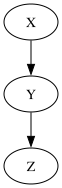

In [5]:
import graphviz as gr

g=gr.Digraph()
g.edge("X","Y")
g.edge("Y","Z")
g

- Let's take the example above; we know for a fact that $X$ causes $Y$ and $Y$ causes $Z$
- If this is the only chain of causality (i.e. nothing else causes $Y$ besides $X$, and nothing else causes $Z$ besides $Y$), then knowing either one is sufficient to tell you $Z$
    - That is, if I know $X$, adding $Y$ tells me nothing new about $Z$ (and vice versa)
    - Mathematically, $E[Z | X,Y] = E[Z | X] = E[Z | Y]$

- This causal chain suggests that $Z$ is not independent of $X$ (because $X$ causes $Y$ which causes $Z$)
    - That is, $Z \not\perp X$
    - However, if we were to know $Y$ perfectly, then knowing $X$ adds no value, and $Z$ becomes independent on $X$ when conditioning on $Y$
        - That is, when we fix $Y$, variation in $Z$ cannot be due to variation in $X$, and they are therefore independent
    - Therefore, $Z \perp X | Y$

#### Backdoor Path

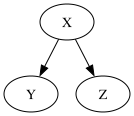

In [6]:
import graphviz as gr

g = gr.Digraph()
g.edge('X', "Y")
g.edge('X', "Z")
g

- A **backdoor path** occurs when you have $X$ causing both $Y$ and $Z$ at the same time

- Here, we know that $Y$ and $Z$ are not independent
    - Why? Because they are caused by the same $X$
    - So if we know that $Z$ is high, then $X$ must be high, and so $Y$ should also be high
    - Therefore $Y \not\perp Z$

- BUT once we condition on $X$, $Y$ and $Z$ are now independent
    - That is, when we fix $X$, the variation in $Z$ no longer has any link to variation in $Y$
    - Therefore $Y \perp Z$

#### Collider

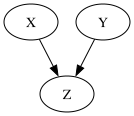

In [7]:
import graphviz as gr

g = gr.Digraph()
g.edge('X','Z')
g.edge('Y','Z')
g

- A **collider** occurs when you have $X$ and $Y$ both causing $Z$

- Here, we know that $X$ and $Y$ are independent
    - Why? Because they are not connected to each other; knowing the value of $X$ doesn't tell us anything about $Y$
    - Therefore $X \perp Y$

- BUT once we condition on $Z$, $X$ and $Y$ are now dependent on each other!
    - Once we know that $Z$ is high, then knowing that $X$ is low must tell us that $Y$ is high
    - Therefore $X \not\perp Y$

#### Summary

- These 3 structures form the basis of all causal language. Everything else is just conclusions drawn based on combinations of these rules
- What's interesting is that these rules can be applied to larger graphs, not just basic 3 node graphs. Let's step through an example below
- You'll notice that in my answers, I have avoided justifying the reason using jargon (i.e. I do not say that "$X \perp Y$ because a collider is not conditioned on")
    - I find such explanations unsatisfactory; it is far better to reason these things from first principles

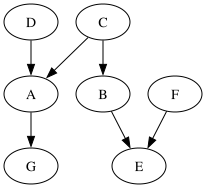

In [8]:
import graphviz as gr

g = gr.Digraph()
g.edge('D', "A")
g.edge('C', "A")
g.edge('A', "G")
g.edge('C', "B")
g.edge('B', "E")
g.edge('F', "E")
g

- Is $D \perp C$?
    - Yes, because $D$ has no relation with $C$
    - Had we known $A$, then we would have been able to conclude $C$ from $D$

- Is $D \perp C | A$
    - No, $D \not\perp C | A$
    - Now, we know $A$, so if $D$ is high, and $A$ is low, then $C$ must be low 
    - For example, if $D$ is water and $C$ is sunlight, and $A$ is plant growth
    - Assuming we know that plant growth is high, but water is low. Then sunlight must be super high 

- Is $D \perp C | G$
    - No, $D \not\perp C | G$
    - Similar idea as the previous case. 
    - By knowing $G$, we know $A$
    - Consequently, the inputs $D$ and $C$ are not independent

- Is $A \perp F$
    - Yes, $A \perp F$
    - Knowing $A$ tells us nothing about $F$ because they are not directly joined along any causal path
    - Complication: But doesn't knowing A tell us C, which tells us B, which tells us E, which tells us F?
        - The point is that you need to know $E$ first, which the question explicitly excludes

- Is $A \perp F | E$
    - No, $A \not\perp F | E$
    - Continuing from the discussion above, we know that once you fix E, then any change in $A$ must have a corresponding change in $F$ (because they jointly cause $E$, and $E$ is fixed)
    
- Is $A \perp F | E,C$
    - Yes $A \perp F | E,C$
    - This is where things get a little confusing, so let's reason things out bit by bit
    - Let's look at 2 subproblems
        - we know that $A \not\perp F | E$
            - Why? Because once $E$ is fixed, movements of direct inputs $F$ and $B$ must cancel each other out. (else, $E$ would change)
            - So if $F$ cannot move independently of $B$, and $B$ cannot move independently of $C$, and movement in $C$ will cause movement in $A$, THEN it must be true that $A \not\perp F | E$
        - we know that $A \perp F | C$
            - Why? Because if we fix $C$, all variation in $A$ must come from $D$
            - Therefore, variation in $A$ does not give us any more information about $C$, and it is thereby independent
    - Both subproblems give us different conclusions!! Which takes precedence?
    - Let's puzzle it out
        - We are also told that we know $C$
        - So any variation in $A$ must be the result of something else outside of $C$
        - Since $C$ is fixed, $B$ is fixed, and we know that $E$ is known
        - Therefore, it must be the case that $F$ is known; because both $C$ and $E$ are not varying
        - Therefore, no variation in $A$ can possibly affect $F$

### Biases in Causal Inference

- Having established the causal graph languages, we now discuss 2 sources of bias in causal inference: **Confounding Bias**, and **Selection Bias**

#### Confounding Bias

- This happens when both the treatment and outcome share a common cause (i.e. there is some common upstream variable that causes both the treatment and the outcome)

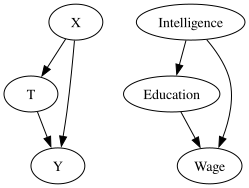

In [21]:
import graphviz as gr

g = gr.Digraph()
g.edge('X', 'T')
g.edge('X', 'Y')
g.edge('T', 'Y')

g.edge('Intelligence', 'Education')
g.edge('Intelligence', 'Wage')
g.edge('Education', 'Wage')

g

- Suppose we want to measure the causal effect of education on wage; `Wage ~ Education`

- If we do not control for intelligence, there is confounding bias. 

- Why? 
    - Education varies as a result of intelligence
    - Wage varies as a result of intelligence
    - As a result, when intelligence increases, both education and wage increas too
    - Let's imagine we live in a world where Education has 0 impact on Wage
    - Then if we run the usual regression of Wage against Education without controlling for intelligence, there will be cases where Education and Wage vary in the same direction at the same time due to variation in intelligence
    - This is how confounding bias occurs!

##### Example 1

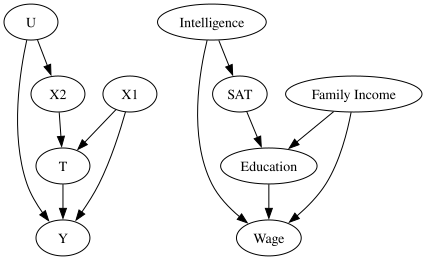

In [22]:
import graphviz as gr
g = gr.Digraph()
g.edge('U', 'Y')
g.edge('X1', 'T')
g.edge('U', 'X2')
g.edge('X2', 'T')
g.edge('T', 'Y')
g.edge('X1', 'Y')

g.edge('Intelligence', 'Wage')
g.edge('Intelligence', 'SAT')
g.edge('SAT', 'Education')
g.edge('Education', 'Wage')
g.edge('Family Income', 'Education')
g.edge('Family Income', 'Wage')

g

- Let's look at a more realistic example

- We want to know whether our treatment $T$ (in this case Education) affects outcome $Y$, (in this case Wage)

- Let's assume that education affects wage. That is $E[\text{Wage} | \text{Education = high}] \neq E[\text{Wage} | \text{Education = low}]$ So $\text{Education} \perp \text{Wage}$ 

- But education is affected in turn by intelligence (indirectly), SAT (directly), and family income (directly)

- If we simply do `Wage ~ Education`, the confounding effects of intelligence, SAT, and Family income are not accounted for
    - For example, one could argue that more intelligent people do better at SAT, and consequently get more education, thereby increasing wages.
    - As such, without controlling for the effect of intelligence on education, we would falsely attribute the component of wage that increased because of intelligence to the effect of education on wage
    - For example
        - suppose intelligence increases SAT by 10%, which increased education by 10%, which increased wages by 10%
        - suppose also that there is random variation in education, which simultaneously increased Wage by another 5%
        - without accounting for the effect of intelligence on education, we would overstate the effect of education on wage as 15%

- So in this case, how do we control for any backdoor?
    - Simple! We condition on the covariates $X_1, X_2$ to close the backdoor
    - But wait, $U$ also affects $Y$, and this is not accounted for in our model
    - But remember, all we care about is estimating the effect of $T$ on $Y$ accurately
    - Once we condition on $X_1, X_2$, there is no path to $Y$ **through $T$**
    - Therefore, any measured effect of $T$ on $Y$ is unbiased

- That is, $(Y_0, Y_1) \perp T | X_1, X_2$
    - Remember, we are **NOT** saying that $Y \perp T$ 
    - T could affect Y
    - But the **set of potential outcomes** $(Y_0, Y_1)$ will not change regardless of whether $T=1$ or $T=0$


##### Example 2

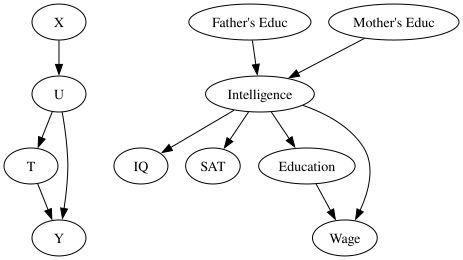

In [25]:
g = gr.Digraph()
g.edge("X", "U")
g.edge("U", "T")
g.edge("T", "Y")
g.edge("U", "Y")

g.edge("Intelligence", "IQ")
g.edge("Intelligence", "SAT")
g.edge("Father's Educ", "Intelligence")
g.edge("Mother's Educ", "Intelligence")

g.edge("Intelligence", "Education")
g.edge("Education", "Wage")
g.edge("Intelligence", "Wage")

g

- Let's think through another example

- In this case, we have the classic case of confounding, where $U$ affects $T$, and $U$ also affects $Y$
    - That is, intelligence affects Education, and also Wage

- But wait, we have a problem! Intelligence cannot be measured!!!

- So instead of trying to measure intelligence, we try to use **surrogate variables** to account for the effect of intelligence
    - That is, instead of doing `Wage ~ Intelligence + Educ`, we do `Wage ~ Father's Education + Mother's Education + Education + IQ + SAT`

#### Selection Bias

- So far, our analysis seems to be leading us to conclude that there is no cost to adding variables, because even if it isn't causally linked to the outcome (i.e. no direct path to outcome), it can always be a surrogate variable to something that is 

- However, life isn't that simple

- The second significant source of bias in our universe comes from selection bias

##### Example 1

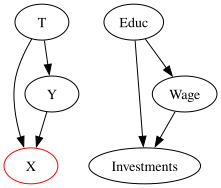

In [26]:
g = gr.Digraph()
g.edge("T", "X")
g.edge("T", "Y")
g.edge("Y", "X")
g.node("X", "X", color="red")

g.edge("Educ", "Investments")
g.edge("Educ", "Wage")
g.edge("Wage", "Investments")

g

- Let's take this basic example to illustrate the point

- Let's suppose, for the sake of argument, that we've randomised education

- We assume that investments are the product of education and wage
    - The more you earn, the more you have to invest
    - The more educated you are, the more you invest

- Before conditioning on investments, since we've randomised education, we can conclude that $E[Y_0 | T = 1] = E[Y_0 | T = 0]$
    - That is $(Y_0, Y_1) \perp T$

- What happens when we condition in investments?
    - Let's say investments is a binary, either yes or no
    - When we condition on investments, we are "holding investment constant". Let's do this, conditioning on investments being "yes"
        - That is, we look at the subsegment of people who have invested
    - Let's discuss the **potential outcomes** of individuals who are educated and have invested vs the individuals who are not educated and have invested
        - Here, E=1/E=0, I=1/I=0 refers to the group the individuals are in
        - $(Y_1, Y_0)$ refers to the outcomes observed for an individual **HAD THEY BEEN** randomised to treatment/control

        - Potential outcome if educated for individual who is in educated group and invested: $Y_1 | {T=1,I=1}$
        - Potential outcome if not educated for individual who is in educated group and invested: $Y_0 | {T=1,I=1}$
        - Potential outcome if educated for individual who is in not educated group and invested: $Y_1 | {T=0,I=1}$
        - Potential outcome if not educated for individual who is not in educated group and invested: $Y_0^{T=0,I=1}$
    
    - In an ideal world, with randomisation, $Y_1^{E=1,I=1} = Y_1^{E=0,I=1}$ and $Y_0^{E=1,I=1} = Y_0^{E=0,I=1}$
    
    - But once you condition on investments, this may no longer hold. Why?
        - Because assuming education and wage both cause investment, once you subset to everyone who has invested, the uneducated people who have invested must be making more on average compared to the educated people who have invested
        - And so, this must also be the group of people with unobservered confounding variables (e.g. higher motivation, higher personal efficacy etc)
        - As a result, it is possible that $E[Y_0 | {T=1,I=1}] < E[Y_0 | {T=0,I=1}]$

- In jargon, you have conditioned on a collider, which **opens a path**
    - This can be true even if the collider isn't directly connected to $Y$!

##### Example 2

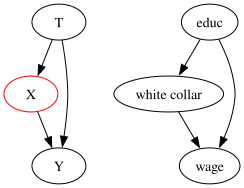

In [27]:
g = gr.Digraph()
g.edge("T", "X")
g.edge("T", "Y")
g.edge("X", "Y")
g.node("X", "X", color="red")

g.edge("educ", "white collar")
g.edge("educ", "wage")
g.edge("white collar", "wage")

g

- Selection bias can also be caused when you condition on a **mediator**
    - That is, you condition on a variable that sits in between treatment and outcome

- Why?
    - Again, let's assume that education has been randomised
    - Let's suppose we condition on the job type: "white collar job"; that is, we subset to everyone with a "white collar job" 
    - But among those who are not educated and hold a white collar job, surely there are unobserved confounders (i.e. more hardworking etc)
    - So subsetting to only those who are white collar, the effect of education is dampened!!
    - Because the confounders for uneducated white collar workers basically causes higher than expected wage, which lowers the wage differential between educated and non-educated observations 